## 1.Configuration and imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import catboost


sns.set_theme(style='darkgrid',palette='muted')

pd.set_option('display.float_format', '{:.2f}'.format)
flats = pd.read_csv('flats.csv')
flats = flats.drop('Street',axis=1)

flats['Floor'] = flats['Floor'].replace('parter', 0)
flats['Floor'] = flats['Floor'].astype(int)
flats['Price_Per_m2'] =  (flats['Price'] / flats['Square_Footage']).round(2)

price_limit = flats['Price'].quantile(0.98)
sqm_limit = flats['Square_Footage'].quantile(0.98)
price_btm_limit = flats['Price'].quantile(0.02)
sqm_btm_limit = flats['Square_Footage'].quantile(0.02)
ppm2_limit = flats['Price_Per_m2'].quantile(0.98)
ppm2_btm_limit = flats['Price_Per_m2'].quantile(0.02)

flats_filtred = flats[(flats['Price'] <= price_limit) & (flats['Price'] >= price_btm_limit) & 
                      (flats['Square_Footage'] >= sqm_btm_limit) & (flats['Square_Footage'] <= sqm_limit) &
                      (flats['Price_Per_m2'] >= ppm2_btm_limit) & (flats['Price_Per_m2'] <= ppm2_limit)]
flats_filtred.dtypes



Name                  str
Price               int64
Square_Footage    float64
Rooms               int64
Floor               int64
Estate                str
District              str
Price_Per_m2      float64
dtype: object

In [ ]:
balcony_keywords = [
    'balkon', 'balkonu', 'balkonem', 'balkony', 'balkonami', 'balkonowy', 
    'taras', 'tarasu', 'tarasem', 'tarasie', 'tarasy', 'tarasów', 'tarasami',
    'loggia', 'loggi', 'loggią', 'loggie', 'loggiami', 'loggiei',
    'balkon_komórka', 'balkon18m2', 'balkony_bez', 'balkony_budowa', 
    '42m²balkon', 'pokoje_loggia'
]

garage_keywords = [
    '2garaz', '2garaże', '2xgaraż', 'factory_garaż', 'garaz', 'garazu', 
    'garaż', 'garaż_', 'garażami', 'garaże', 'garażem', 'garażowa', 
    'garażowa_zobacz', 'garażowe', 'garażowy', 'garażowymi', 'garażową', 
    'garażu', 'komórka_garaż', 'otwarte_metro_garaż',
    '2mpostojowe', 'dwumiejscowym', 'iparking', 'parking', 'parkingi', 
    'parkingiem', 'parkingow', 'parkingowe', 'parkingowym', 'parkingowymi', 
    'postoj', 'postojem', 'postojo', 'postojowe', 'postojowym', 'postojowymi',
    'miejsc', 'miejsca', 'miejscami', 'miejsce', 'miejscem', 'miejscu'
]

garden_keywords = ["ogródek", "ogródkiem", "ogród", "ogrodem", "ogródki", "ogródkami", 
            "ogrody", "ogrodzie", "ogrodu", "ogródka", "ogrodami", "ogróde", "ogrodkiem", 
            "iogródek", "ogródekiem", "ogródu", "ogród60mkw", "ogrodem_hala", "do_remontu_z_ogródkiem_obustronne_do_negocjacji"]

metro_keywords = ['metro', 'metra', 'metrze', 'metrem','metroratusz', 'dolinkąmetro', 
    '_metro', 'otwarte_metro', 'metroart', 'wielkanocny_metro', 'otwarte_metro_garaż'
]


patterns_to_columns = {
    'is_ready': ['nowy', 'nowa', 'nowe', 'gotowe', 'pod klucz', 'wykończony', 'wykończone', 'do wprowadzenia', 'do wejścia', 'do zamieszkania'],
    'needs_renovation': ['do remontu', 'do odświeżenia', 'do wykończenia', 'do aranżacji', 'do własnej aranżacji'],
    'is_renovated': ['po remoncie', 'po generalnym remoncie', 'wyremontowane', 'odświeżone'],
    'is_developer_state': ['deweloperski', 'stan deweloperski'],
    'is_premium': ['wysoki standard', 'premium', 'idealny', 'idealnym', 'świetny', 'zadbany', 'zadbane']
}

warsaw_districts = [
    'Mokotów', 'Wola', 'Białołęka', 'Praga-Południe', 'Śródmieście', 
    'Ursus', 'Ursynów', 'Włochy', 'Bemowo', 'Wilanów', 'Ochota', 
    'Targówek', 'Bielany', 'Praga-Północ', 'Wawer', 'Żoliborz', 
    'Rembertów', 'Wesoła'
]

premium_keywords = [
    "apartament","premium","penthouse","luksusowy","luksus",
    "wysoki standard","ekskluzywny","prestiżowy",
    "prestiż","wyjątkowy","residence","rezydencja","vip"
]

districs_correct = {
    'Kabaty': 'Ursynów',
    'Skorosze': 'Ursus',
    'Stegny': 'Mokotów'
}

for col_name, patterns in patterns_to_columns.items():
  
    regex_pattern = '|'.join(patterns)
    
   
    flats_filtred[col_name] = flats_filtred['Name'].str.contains(
        regex_pattern, 
        case=False, 
        na=False, 
        regex=True
    ).astype(int)

polish_signs = str.maketrans('ąćęłńóśźżĄĆĘŁŃÓŚŹŻ', 'acelnoszzACELNOSZZ')
flats_filtred['District'] = flats_filtred['District'].replace(districs_correct)
flats_filtred = flats_filtred[flats_filtred['District'].isin(warsaw_districts)]

pattern_balcony = '|'.join(balcony_keywords)
pattern_garage = '|'.join(garage_keywords)
pattern_garden = '|'.join(garden_keywords)
pattern_metro = '|'.join(metro_keywords)
pattern_premium = '|'.join(premium_keywords)

flats_filtred['Has_Balcony'] = flats_filtred['Name'].str.contains(pattern_balcony,case=False,na=False).astype(int)
flats_filtred['Has_Garage'] = flats_filtred['Name'].str.contains(pattern_garage,case=False,na=False).astype(int)
flats_filtred['Has_Garden'] = flats_filtred['Name'].str.contains(pattern_garden,case=False,na=False).astype(int)
flats_filtred['Has_Metro'] = flats_filtred['Name'].str.contains(pattern_metro,case=False,na=False).astype(int)
flats_filtred['Is_Premium'] = flats_filtred['Name'].str.contains(pattern_premium,case=False,na=False).astype(int)


flats_filtred.columns   

Index(['Name', 'Price', 'Square_Footage', 'Rooms', 'Floor', 'Estate',
       'District', 'Price_Per_m2', 'is_ready', 'needs_renovation',
       'is_renovated', 'is_developer_state', 'is_premium', 'Has_Balcony',
       'Has_Garage', 'Has_Garden', 'Has_Metro', 'Is_Premium', 'is_Białołęka',
       'is_Bielany', 'is_Mokotów', 'is_Ochota', 'is_Praga-Południe',
       'is_Praga-Północ', 'is_Rembertów', 'is_Targówek', 'is_Ursus',
       'is_Ursynów', 'is_Wawer', 'is_Wesoła', 'is_Wilanów', 'is_Wola',
       'is_Włochy', 'is_Śródmieście', 'is_Żoliborz'],
      dtype='str')

Text(0, 0.5, 'Liczba ofert')

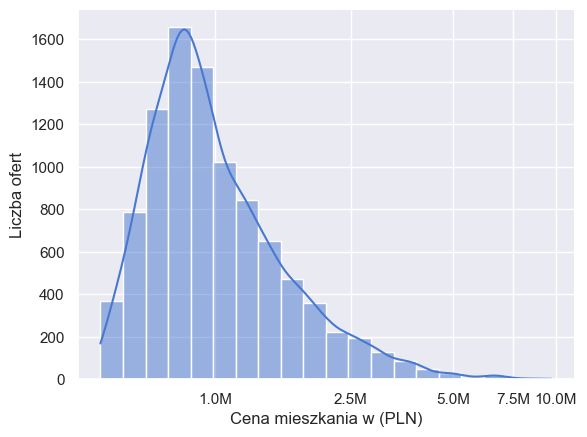

In [19]:
def format_prices(x, pos):
    if x >= 1e6:
        return f'{x*1e-6:.1f}M' 
    elif x >= 1e3:
        return f'{x*1e-3:.0f}k'
    return f'{x:.0f}'

ax = sns.histplot(data=flats_filtred,x='Price',bins=20,kde=True,log_scale=True)
sns.despine()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_prices))

custom_ticks = [1_000_000, 2_500_000, 5_000_000, 7_500_000, 10_000_000]
ax.set_xticks(custom_ticks)

plt.xlabel("Cena mieszkania w (PLN)",fontsize=12)
plt.ylabel("Liczba ofert",fontsize=12)

Text(0, 0.5, 'Liczba ofert')

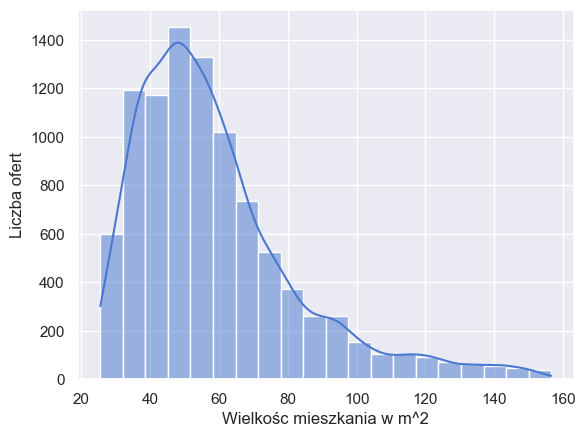

In [20]:
sns.histplot(data=flats_filtred,x='Square_Footage',bins=20,kde=True)

plt.xlabel("Wielkośc mieszkania w m^2",fontsize =12)
plt.ylabel("Liczba ofert",fontsize=12)


Text(0, 0.5, 'Liczba ofert')

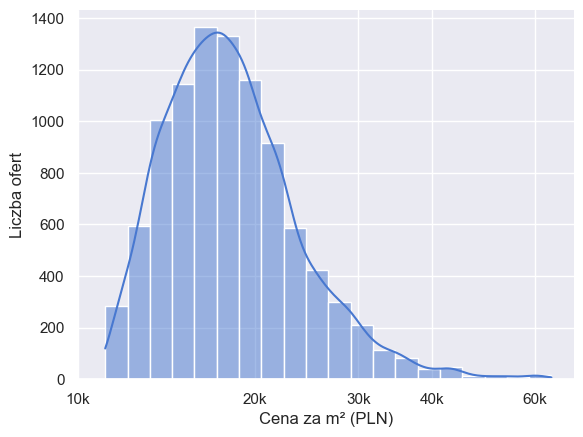

In [21]:
def format_prices_per_meter(x, pos):
    if x >= 1000:

        return f'{x / 1000:.0f}k' 
    return f'{x:.0f}'

ax2 = sns.histplot(data=flats_filtred,x='Price_Per_m2',bins=20,kde=True,log_scale=True)
sns.despine()

custom_ticks = [10000, 20000, 30000, 40000, 60000]
ax2.set_xticks(custom_ticks)

ax2.xaxis.set_major_formatter(ticker.FuncFormatter(format_prices_per_meter))
plt.xlabel("Cena za m² (PLN)", fontsize=12)
plt.ylabel("Liczba ofert", fontsize=12)


Text(0, 0.5, 'Liczba mieszkań')

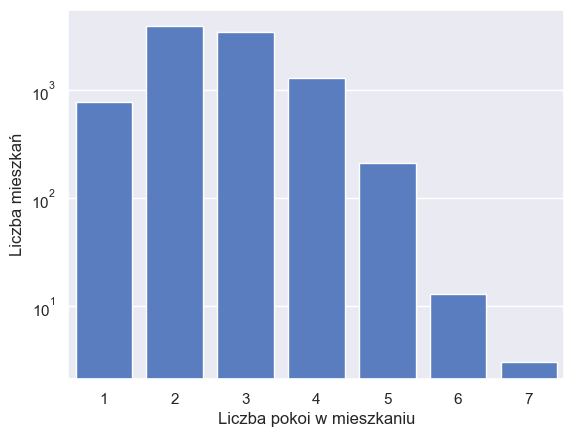

In [22]:
ax = sns.countplot(data=flats_filtred,x='Rooms')
plt.xlabel('Liczba pokoi w mieszkaniu',fontsize=12)
ax.set_yscale("log")
plt.ylabel('Liczba mieszkań',fontsize=12)

Text(0, 0.5, 'Liczba mieszkań')

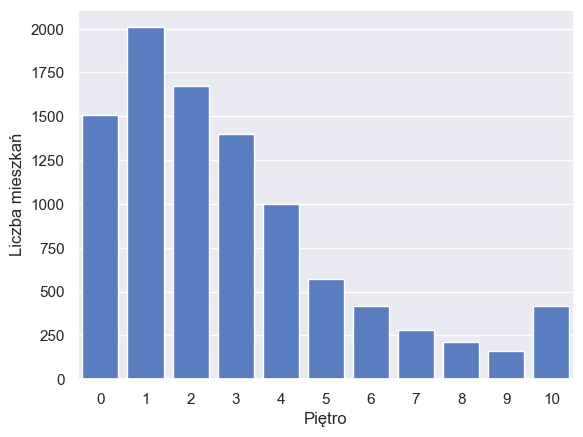

In [23]:
sns.countplot(data=flats_filtred,x='Floor')

plt.xlabel('Piętro',fontsize=12)
plt.ylabel('Liczba mieszkań',fontsize=12)


Text(0.5, 1.0, 'Heatmapa cen mieszkań')

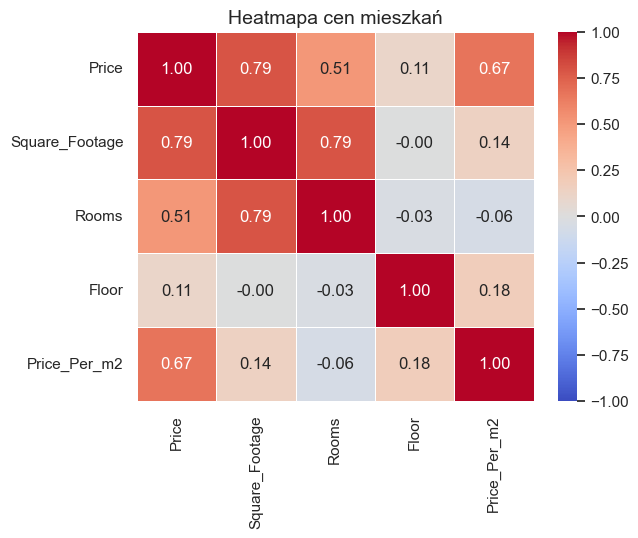

In [24]:
num_cols = ['Price', 'Square_Footage', 'Rooms', 'Floor', 'Price_Per_m2']
corr_matrix = flats_filtred[num_cols].corr()

sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',vmin=-1, vmax=1, linewidths=0.5)

plt.title('Heatmapa cen mieszkań',fontsize=14)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'Mokotów'),
  Text(1, 0, 'Wola'),
  Text(2, 0, 'Białołęka'),
  Text(3, 0, 'Praga-Południe'),
  Text(4, 0, 'Śródmieście'),
  Text(5, 0, 'Ursus'),
  Text(6, 0, 'Ursynów'),
  Text(7, 0, 'Włochy'),
  Text(8, 0, 'Bemowo'),
  Text(9, 0, 'Wilanów'),
  Text(10, 0, 'Targówek'),
  Text(11, 0, 'Ochota'),
  Text(12, 0, 'Bielany'),
  Text(13, 0, 'Praga-Północ'),
  Text(14, 0, 'Wawer'),
  Text(15, 0, 'Żoliborz'),
  Text(16, 0, 'Rembertów'),
  Text(17, 0, 'Wesoła')])

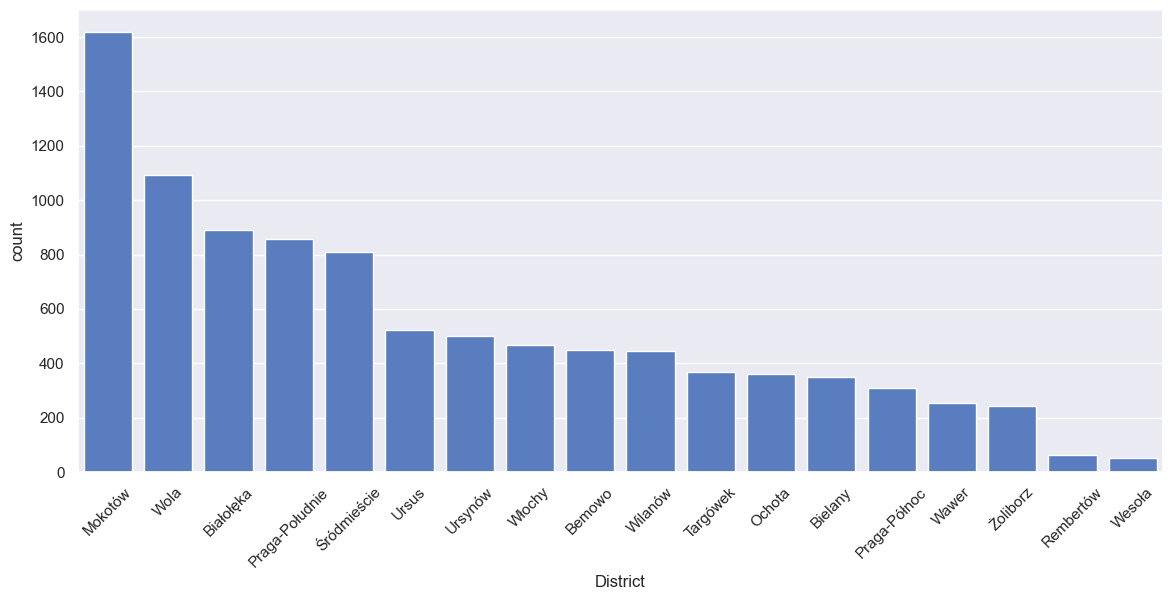

In [25]:
plt.figure(figsize=(14, 6))
district_order = flats_filtred['District'].value_counts().index
sns.countplot(flats_filtred,x='District',order=district_order)
plt.xticks(rotation = 45)

Text(0.5, 0, 'Dzielnica')

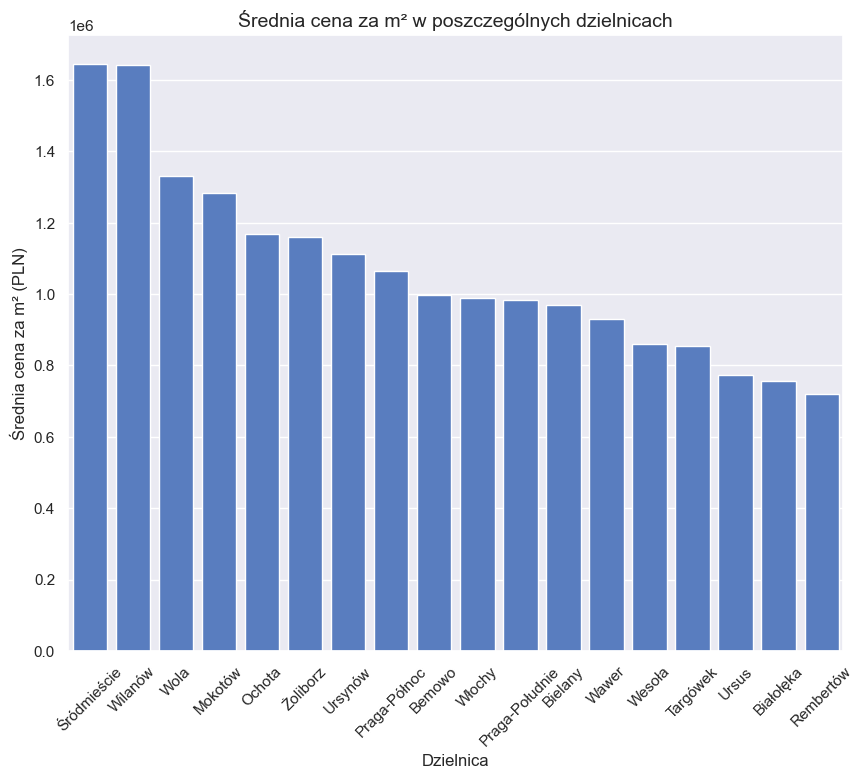

In [26]:
district_mean_price = flats_filtred.groupby('District')['Price'].mean().reset_index().sort_values(by='Price',ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(data=district_mean_price,x='District',y='Price')
plt.xticks(rotation = 45)
plt.title('Średnia cena za m² w poszczególnych dzielnicach', fontsize=14)
plt.ylabel('Średnia cena za m² (PLN)', fontsize=12)
plt.xlabel('Dzielnica', fontsize=12)

Text(0.5, 0, 'Cena całkowita (PLN)')

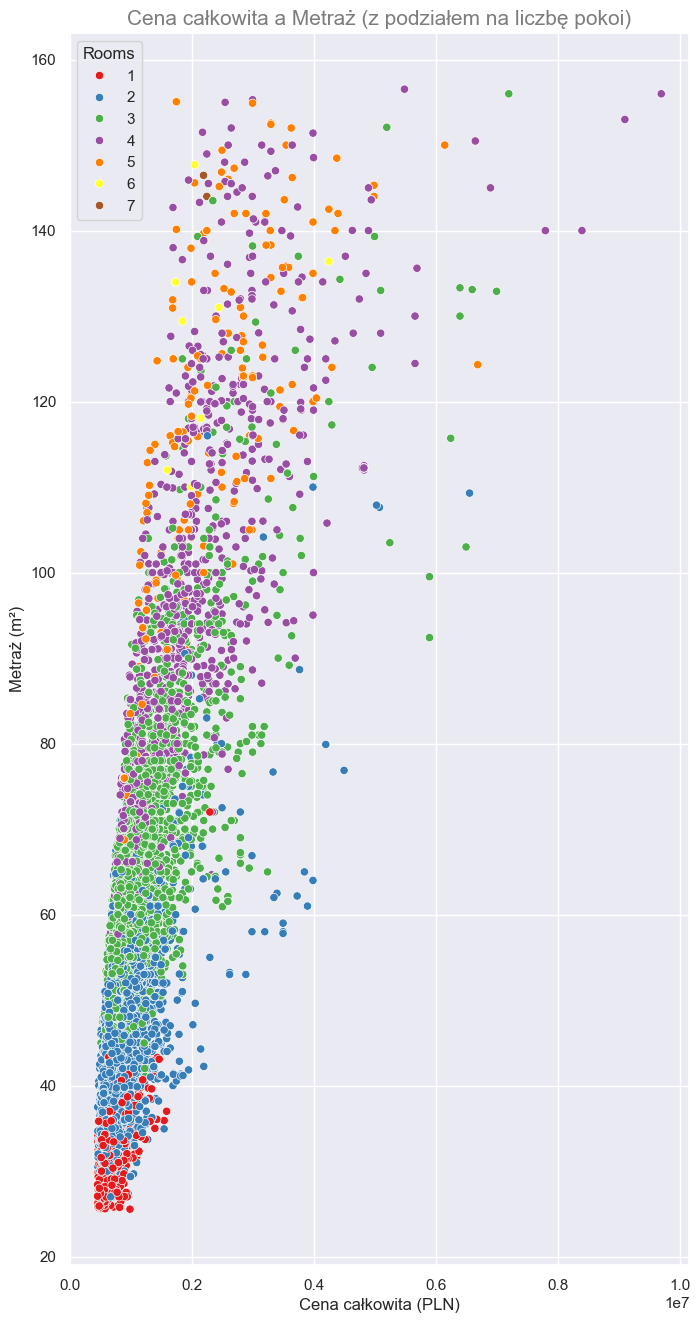

In [27]:
plt.figure(figsize=(8,16))
sns.scatterplot(data=flats_filtred,x='Price',y='Square_Footage',hue='Rooms',palette='Set1')

plt.title('Cena całkowita a Metraż (z podziałem na liczbę pokoi)', fontsize=15,alpha=0.6)
plt.ylabel('Metraż (m²)', fontsize=12)
plt.xlabel('Cena całkowita (PLN)', fontsize=12)

In [ ]:
y = flats_filtred['Price_Per_m2']
x = flats_filtred.drop(columns=['Name', 'Price', 'Price_Per_m2'])


def categorize_floor(floor):
    if floor == 0: 
        return 'Parter'
    elif 1 <= floor <= 3: 
        return 'Niskie'
    elif 4 <= floor <= 8: 
        return 'Srednie'
    else: 
        return 'Wysokie'

flats_filtred['Floor_Cat'] = flats_filtred['Floor'].apply(categorize_floor)

cat_features = ['Estate','District','Floor_Cat']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state =42)
model = catboost.CatBoostRegressor(n_estimators=1500, random_state=42, cat_features=cat_features, depth=6, learning_rate=0.05,verbose=100)
model.fit(x_train,y_train)
predictions = model.predict(x_test)
pred_train = model.predict(x_train)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Błąd na zbiorze treningowym (MAE): {mean_absolute_error(y_train, pred_train):.2f}")
print(f"Błąd na zbiorze testowym (MAE): {mean_absolute_error(y_test, predictions):.2f}")

print(f"Średni błąd (MAE): {mae:.2f}")
print(f"Błąd średniokwadratowy (RMSE): {rmse:.2f}")
print(f"Współczynnik R^2: {r2:.4f}")


ValueError: list.index(x): x not in list